# RL Project: Delivery Robot
**Advanced Topics in Machine Learning (S411021)**  

GSEM, University of Geneva - Spring Semester 2026


## Task 1 - MDP Formulation

### (a) State space, action space, and reward set

**State space $(\mathcal{S})$**

A state must encode everything that influences future transitions and rewards. Two quantities are necessary and sufficient: the robot’s *position* \(p\) and its *battery level* \(b\).

One can say: Because the episode ends as soon as the robot reaches the target \(t = 9\), only positions before the target are relevant. Therefore we  can use

$\mathcal{S'} = \bigl\{ (p,\,b) \mid p \in \{0,\dots,t-1\},\; b \in \{0,\dots,M\} \bigr\} \;\cup\; \{s_\top\}$

where $s_\top$ is the single absorbing terminal state entered on any episode-ending event (successful delivery, battery depletion while moving, or any illegal action).

$|\mathcal{S'}| = t(M+1) + 1 $


This may not be the compactest representation, still one can argue that the poistions like (p,10) aren't reachable because the robot cannot be there at full battery unless it's the battery stations but since we don't know which positions are charging stations and this makes the representaion of the state space more complex to impliment we can simply stick to the full state space. Nevertheless, the dynamic-programming and Monte-Carlo algorithms do not collapse and produce identical results: the transition matrix (and the absorbing nature of the target) assigns zero probability to any transition that would enter an unreachable state ($p \geq t$). Consequently, the value function and optimal policy remain exactly the same whether the unreachable states are included in the table or not; they simply stay at their initial value and are never visited. Another important thing is if we want to change our starting position for different experiments, we don't need to change the state space, we can simply start at a different position and the unreachable states will still be unreachable.

So we defiened and used this state space for the project:

$\mathcal{S} = \bigl\{ (p,\,b) \mid p \in \{0,\dots,n-1\},\; b \in \{0,\dots,M\} \bigr\} \;\cup\; \{s_\top\} $

$|\mathcal{S}| = n(M+1) + 1 $

**Action space $(\mathcal{A})$**

All three actions are allowed in **every** state (as required by the task statement). Illegal actions are simply handled by the transition dynamics (they end the episode with a penalty).

| ID | Name     | Description                              |
|----|----------|------------------------------------------|
| 0  | LEFT     | Attempt to move one step left            |
| 1  | RIGHT    | Attempt to move one step right           |
| 2  | CHARGE   | Charge battery by +1 unit (if possible)  |

$\mathcal{A} = \{LEFT,\; RIGHT,\; CHARGE\}$

**Reward set $(\mathcal{R})$**

| Event                                      | Reward      |
|--------------------------------------------|-------------|
| Successful delivery (reach target \(t\))   | \(+10\) CHF |
| Battery depleted while moving / illegal action (including charging at full battery or not at a charger) | \(-10\) CHF |
| Legal charge at a charging station         | \(-1\) CHF  |
| Legal move that does **not** reach target  | \(0\) CHF   |


$\mathcal{R} = \{-10,\; -1,\; 0,\; +10\}$


### (b) Is $\gamma < 1$ necessary?

The problem is episodic, the robot always terminates by either reaching the target or failing due to battery depletion or an illegal action. Therefore $\gamma < 1$ is not strictly necessary for the Bellman operator to be well-defined or for DP to converge.

However, using $\gamma = 0.95$ is appropriate for two reasons. First, it guarantees contraction of the Bellman operator independent of episode structure. Second, and more naturally, it encodes a preference for reaching the target sooner. A longer delivery takes longer time and is therefore less valuable, which is economically sensible.


### (c) Pickup-before-delivery extension

If the robot must first pick up the package from a location $s \in \mathcal{P}_n$ before it can deliver it at the target $t$, the state $(p, b)$ alone no longer preserves the Markov property. The reward (and termination) upon reaching $t$ now depends on whether the package has already been collected, which is not encoded in position or battery level.

We therefore augment the state with a binary cargo flag $k \in \{0,1\}$, where $k=0$ means the package has not yet been picked up and $k=1$ means the robot is carrying the package.

The new state space becomes


$\mathcal{S}' = \bigl\{ (p, b, k) \mid p \in \{0,\dots,n-1\},\; b \in \{0,\dots,M\},\; k \in \{0,1\} \bigr\} \cup \{s_\top\}$

with


$|\mathcal{S}'| = n \times (M+1) \times 2 + 1$

states (using the full path $\mathcal{P}_n$) because the pickup location $s$ can lie anywhere and the robot may need to traverse the entire line).

The **action space $\mathcal{A}$** and **reward set $\mathcal{R}$** remain exactly the same as in part (a). Only the transition dynamics change:

- When $k=0$ and the robot reaches position $p=s$: the package is picked up automatically ($k = 1$) with reward $0$ (episode continues).
- When $k=1$ and the robot reaches position $p=t$: delivery is successful then reward $+10$ and transition to the terminal state $s_\top$.
- When $k=0$ and the robot reaches $p=t$: nothing special happens (reward $0$, episode continues).
- All other transitions (moves, charging, illegal actions, battery depletion) behave exactly as in the original MDP.

This extension restores the Markov property by explicitly tracking the delivery status in the state.


## Task 2 - Environment Implementation


In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [ ]:
class DeliveryRobotEnv:
    """All possible (position, battery) pairs in the environment.
        
        This returns the *full* state space of size n(M+1) = 220,
        including positions after the target (which are unreachable).
        
        In Task 1(a) we mentioned the compact reachable set.
        We keep the full space here for generality: unreachable states have
        zero probability under the transition matrix, so they do not affect
        any DP or MC results. This allows us to see the optimal policy for
        the full setup and makes the class ready for the pickup-before-delivery
        extension without modification.
    """
    # Charge-cost distribution
    CHARGE_COST_VALUES = np.array([1, 2, 3, 4])
    CHARGE_COST_PROBS  = np.array([0.50, 0.35, 0.10, 0.05])

    # Rewards
    REWARD_DELIVERY  =  10.0
    REWARD_PENALTY   = -10.0
    REWARD_CHARGE    =  -1.0
    REWARD_STEP      =   0.0

    # Actions
    LEFT   = 0
    RIGHT  = 1
    CHARGE = 2

    def __init__(self, n=20, M=10, target=9, charging_stations=(2, 6, 14),
                 gamma=0.95, seed=None):
        self.n  = n
        self.M  = M
        self.target = target
        self.charging_stations = set(charging_stations)
        self.gamma = gamma
        self.rng = np.random.default_rng(seed)
        self.reset()

    def reset(self):
        self.position = 0
        self.battery  = self.M // 2
        self.done     = False
        return (self.position, self.battery)

    def step(self, action):
        if self.done:
            raise RuntimeError("Episode is over. Call reset() first.")

        pos, bat = self.position, self.battery

        # CHARGE
        if action == self.CHARGE:
            if pos not in self.charging_stations:
                self.done = True
                return self.REWARD_PENALTY, None, True
            if bat >= self.M:
                self.done = True
                return self.REWARD_PENALTY, None, True
            self.battery = bat + 1
            self.done = False
            return self.REWARD_CHARGE, (self.position, self.battery), False

        # MOVE
        if action == self.LEFT:
            new_pos = pos - 1
        elif action == self.RIGHT:
            new_pos = pos + 1
        else:
            raise ValueError(f"Unknown action {action}")

        if new_pos < 0 or new_pos >= self.n:
            self.done = True
            return self.REWARD_PENALTY, None, True

        cost = self.rng.choice(self.CHARGE_COST_VALUES, p=self.CHARGE_COST_PROBS)

        if bat < cost:
            self.done = True
            return self.REWARD_PENALTY, None, True

        self.battery  = bat - cost
        self.position = new_pos

        if new_pos == self.target:
            self.done = True
            return self.REWARD_DELIVERY, None, True

        return self.REWARD_STEP, (self.position, self.battery), False

    def display(self):
        RESET  = '\033[0m'
        BOLD   = '\033[1m'
        DIM    = '\033[2m'
        BLUE   = '\033[44;97m'   
        GREEN  = '\033[42;97m'   
        AMBER  = '\033[43;30m'   
        cells = []
        for i in range(self.n):
            if i == self.position:
                cells.append(f'{BLUE} R {RESET}')
            elif i == self.target:
                cells.append(f'{GREEN} T {RESET}')
            elif i in self.charging_stations:
                cells.append(f'{AMBER} C {RESET}')
            else:
                cells.append(f'{DIM} {i:<2}{RESET}')

        # Battery bar
        filled  = round((self.battery / self.M) * 10)
        bar     = '#' * filled + '-' * (10 - filled)
        pct     = round(100 * self.battery / self.M)

        status  = 'done' if self.done else 'running'

        print('  ' + ''.join(cells))
        print()
        print(f'  {BOLD}pos{RESET}  {self.position:<4}  '
            f'{BOLD}battery{RESET}  [{bar}] {self.battery}/{self.M} ({pct}%)  '
            f'{BOLD}status{RESET}  {status}')

    @property
    def states(self):
        return [(p, b)
                for p in range(self.n)
                for b in range(self.M + 1)]

    @property
    def actions(self):
        return [self.LEFT, self.RIGHT, self.CHARGE]

    def is_terminal(self, state):
        return state is None

    def transition_probs(self, state, action):
        
        pos, bat = state

        # Target is absorbing (the robot has already delivered, no further actions)
        if pos == self.target:
            return []

        # CHARGE
        if action == self.CHARGE:
            if pos not in self.charging_stations or bat >= self.M:
                return [(1.0, self.REWARD_PENALTY, None)]
            return [(1.0, self.REWARD_CHARGE, (pos, bat + 1))]

        # MOVE
        new_pos = pos - 1 if action == self.LEFT else pos + 1

        if new_pos < 0 or new_pos >= self.n:
            return [(1.0, self.REWARD_PENALTY, None)]

        transitions = []
        for cost, prob in zip(self.CHARGE_COST_VALUES, self.CHARGE_COST_PROBS):
            if bat < cost:
                transitions.append((prob, self.REWARD_PENALTY, None))
            elif new_pos == self.target:
                transitions.append((prob, self.REWARD_DELIVERY, None))
            else:
                transitions.append((prob, self.REWARD_STEP, (new_pos, bat - cost)))
        return transitions


In [3]:
SEED = 17
np.random.seed(SEED)

ENV_KWARGS = dict(n=20, M=10, target=9,
                  charging_stations=(2, 6, 14),
                  gamma=0.95, seed=SEED)
env = DeliveryRobotEnv(**ENV_KWARGS)
s0 = (0, env.M // 2)
print(f'Environment ready. States: {len(env.states)}, s0 = {s0}')

Environment ready. States: 220, s0 = (0, 5)


In [4]:
demo = DeliveryRobotEnv(n=20, M=10, target=9,
                        charging_stations=(2, 6, 14),
                        gamma=0.95, seed=0)

print('=== Initial state ===')
demo.display()

# Move right to charging station 2
for _ in range(2):
    r, ns, done = demo.step(DeliveryRobotEnv.RIGHT)
    print(f'RIGHT -> reward={r:+.0f}, next={ns}, done={done}')
demo.display()

# Charge once
r, ns, done = demo.step(DeliveryRobotEnv.CHARGE)
print(f'CHARGE -> reward={r:+.0f}, next={ns}, done={done}')
demo.display()

# Run right until episode ends
print('\n=== Moving right until episode ends ===')
while not demo.done:
    r, ns, done = demo.step(DeliveryRobotEnv.RIGHT)
    if done:
        demo.display()
        print(f'Episode over! Final reward: {r:+.0f}')


s_init = demo.reset()
print(f'\nAfter reset: {s_init}')
demo.display()

=== Initial state ===
   R  1  C  3  4  5  C  7  8  T  10 11 12 13 C  15 16 17 18 19

  pos  0     battery  [#####-----] 5/10 (50%)  status  running
RIGHT -> reward=+0, next=(1, 3), done=False
RIGHT -> reward=+0, next=(2, 2), done=False
   0  1  R  3  4  5  C  7  8  T  10 11 12 13 C  15 16 17 18 19

  pos  2     battery  [##--------] 2/10 (20%)  status  running
CHARGE -> reward=-1, next=(2, 3), done=False
   0  1  R  3  4  5  C  7  8  T  10 11 12 13 C  15 16 17 18 19

  pos  2     battery  [###-------] 3/10 (30%)  status  running

=== Moving right until episode ends ===
   0  1  C  3  R  5  C  7  8  T  10 11 12 13 C  15 16 17 18 19

  pos  4     battery  [#---------] 1/10 (10%)  status  done
Episode over! Final reward: -10

After reset: (0, 5)
   R  1  C  3  4  5  C  7  8  T  10 11 12 13 C  15 16 17 18 19

  pos  0     battery  [#####-----] 5/10 (50%)  status  running



## Task 3 - Policy Evaluation via Dynamic Programming


We apply iterative policy evaluation (Bellman expectation equations, convergence threshold $\varepsilon = 10^{-9}$) to four fixed policies. For the stochastic Random policy, we evaluate the expected Bellman update analytically over the action distribution rather than sampling.


In [ ]:
def policy_right(state, env):
    return env.RIGHT


def policy_conservative(state, env):
    pos, bat = state
    half = env.M / 2
    if pos in env.charging_stations and bat < half:
        return env.CHARGE
    if pos < env.target:
        return env.RIGHT
    elif pos > env.target:
        return env.LEFT
    else:
        return env.RIGHT


def policy_random(state, env, rng=None):
    
    if rng is None:
        rng = np.random.default_rng()
    pos, bat = state
    if pos in env.charging_stations and bat < env.M:
        if rng.random() < 0.6:
            return env.CHARGE
    return rng.choice([env.LEFT, env.RIGHT])


def policy_chargy(state, env):
    pos, bat = state
    if pos in env.charging_stations and bat < env.M:
        return env.CHARGE
    if bat == env.M or pos in env.charging_stations:
        # Move towards target
        if pos < env.target:
            return env.RIGHT
        else:
            return env.LEFT
    
    stations = sorted(env.charging_stations)
    toward_target = [c for c in stations if (c > pos) == (env.target > pos)]
    if toward_target:
        
        closest = min(toward_target, key=lambda c: abs(c - pos))
    else:
        # No station in the target direction -> go to closest overall
        closest = min(stations, key=lambda c: abs(c - pos))
    if closest > pos:
        return env.RIGHT
    else:
        return env.LEFT


def _random_action_probs(state, env):
    pos, bat = state
    if pos in env.charging_stations and bat < env.M:
        return [(0.20, env.LEFT), (0.20, env.RIGHT), (0.60, env.CHARGE)]
    else:
        return [(0.50, env.LEFT), (0.50, env.RIGHT)]


def policy_evaluation(policy_fn, env, tol=1e-9, max_iter=10000, **policy_kwargs):

    states = env.states
    V = {s: 0.0 for s in states}
    is_random = (policy_fn.__name__ == 'policy_random')

    for _ in range(max_iter):
        delta = 0.0
        V_new = {}
        for s in states:
            if is_random:
                action_probs = _random_action_probs(s, env)
                v = sum(
                    prob_a * sum(
                        p * (r + env.gamma * (V[ns] if ns is not None else 0.0))
                        for p, r, ns in env.transition_probs(s, a)
                    )
                    for prob_a, a in action_probs
                )
            else:
                a = policy_fn(s, env, **policy_kwargs)
                transitions = env.transition_probs(s, a)
                v = sum(p * (r + env.gamma * (V[ns] if ns is not None else 0.0))
                        for p, r, ns in transitions)
            V_new[s] = v
            delta = max(delta, abs(v - V[s]))
        V = V_new
        if delta < tol:
            break
    return V




In [6]:
print('Running policy evaluation ...')
V_right        = policy_evaluation(policy_right,        env)
V_conservative = policy_evaluation(policy_conservative, env)
V_random       = policy_evaluation(policy_random,       env)
V_chargy       = policy_evaluation(policy_chargy,       env)

policies_dp = {
    'Right':        V_right,
    'Conservative': V_conservative,
    'Random':       V_random,
    'Chargy':       V_chargy,
}

print(f'\nValue of initial state s0 = {s0}:')
for name, V in policies_dp.items():
    print(f'  {name:15s}: V(s0) = {V[s0]:+.4f}')

Running policy evaluation ...

Value of initial state s0 = (0, 5):
  Right          : V(s0) = -8.6462
  Conservative   : V(s0) = -8.2916
  Random         : V(s0) = -9.4914
  Chargy         : V(s0) = -6.2158


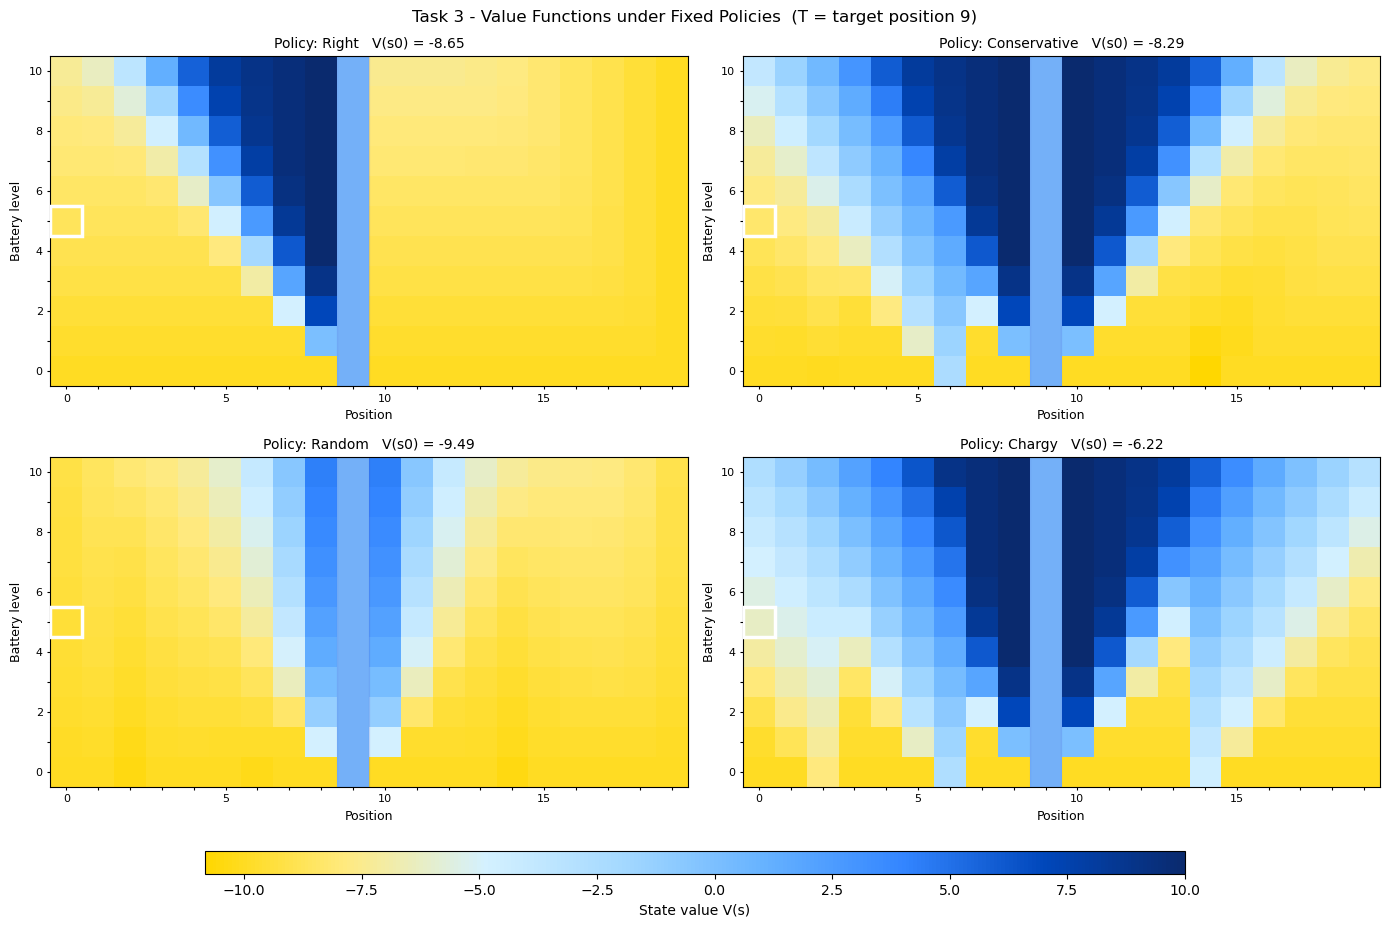

In [7]:
def plot_value_heatmap(V, env, title, ax, vmin, vmax):
    grid = np.full((env.M + 1, env.n), np.nan)
    for (p, b), v in V.items():
        grid[b, p] = v

    # yellow -> blue colormap (low = yellow, high = dark blue)
    cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
        'yb',
        ['#FFD700',        
         '#FFEA80',        
         '#D4F1FF',        
         '#A3D8FF', 
         '#66B2FF', 
         '#3385FF', 
         '#0047BB',        
         '#0A2A6E']         
    )
    
    im = ax.imshow(grid, origin='lower', aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    # Target column tint 
    ax.add_patch(plt.Rectangle(
        (env.target - 0.5, -0.5), 1, env.M + 1,
        color='#4444CC', alpha=0.12, zorder=2))

    # s0 marker (white outline)
    s0p, s0b = 0, env.M // 2
    ax.add_patch(plt.Rectangle(
        (s0p - 0.5, s0b - 0.5), 1, 1,
        fill=False, edgecolor='white', lw=2.5, zorder=4))

    v0 = V[(s0p, s0b)]
    ax.set_title(f'{title}   V(s0) = {v0:.2f}', fontsize=10, pad=6)
    ax.set_xlabel('Position', fontsize=9)
    ax.set_ylabel('Battery level', fontsize=9)
    ax.set_xticks(range(env.n))
    ax.set_xticklabels([str(i) if i % 5 == 0 else '' for i in range(env.n)], fontsize=8)
    ax.set_yticks(range(env.M + 1))
    ax.set_yticklabels([str(b) if b % 2 == 0 else '' for b in range(env.M + 1)], fontsize=8)
    ax.tick_params(length=2)
    return im


all_vals = [v for V in policies_dp.values() for v in V.values()]
vmin, vmax = min(all_vals), max(all_vals)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (name, V) in zip(axes.flatten(), policies_dp.items()):
    im = plot_value_heatmap(V, env, f'Policy: {name}', ax, vmin, vmax)

fig.suptitle('Task 3 - Value Functions under Fixed Policies  (T = target position 9)', fontsize=12)
plt.tight_layout(rect=[0, 0.06, 1, 1])  # leave space at the bottom for the colorbar

cbar_ax = fig.add_axes([0.15, 0.02, 0.7, 0.025])  # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax, orientation='horizontal', label='State value V(s)')

plt.show()

In [8]:
def display_episode(policy_fn, env, seed=42):
    mc_env = DeliveryRobotEnv(
        n=env.n, M=env.M, target=env.target,
        charging_stations=sorted(env.charging_stations),
        gamma=env.gamma, seed=seed
    )
    rng = np.random.default_rng(seed)

    mc_env.reset()
    state = (mc_env.position, mc_env.battery)

    ACTION_NAMES = {0: 'LEFT', 1: 'RIGHT', 2: 'CHARGE'}
    ACTION_REASON = {
        0: 'moving left toward target',
        1: 'moving right toward target',
        2: 'charging battery at station',
    }

    step        = 0
    total_G     = 0.0
    gamma_t     = 1.0
    history     = []

    print('=' * 60)
    print(f' Episode - policy: {policy_fn.__name__}  |  seed: {seed}')
    print('=' * 60)
    print(f'\nInitial state:')
    mc_env.display()
    print()

    done = False
    while not done:
        if policy_fn.__name__ == 'policy_random':
            a = policy_fn(state, mc_env, rng=rng)
        else:
            a = policy_fn(state, mc_env)

        r, next_state, done = mc_env.step(a)
        disc_r   = gamma_t * r
        total_G += disc_r
        history.append((step, ACTION_NAMES[a], r, disc_r, mc_env.position, mc_env.battery))

        print(f'Step {step:>2} - {ACTION_NAMES[a]:>6}  ({ACTION_REASON[a]})')
        print(f'         reward: {r:+.1f}   discounted: {disc_r:+.4f}   cumulative G: {total_G:+.4f}')
        mc_env.display()
        print()

        gamma_t *= env.gamma
        state    = next_state if not done else state
        step    += 1

    print('=' * 60)
    print(f' Summary')
    print('=' * 60)
    print(f'\n  {"Step":>4}  {"Action":>8}  {"Reward":>8}  {"Disc. r":>10}  {"Pos":>5}  {"Bat":>5}')
    print(f'  {"-"*4}  {"-"*8}  {"-"*8}  {"-"*10}  {"-"*5}  {"-"*5}')
    for s, act, r, dr, pos, bat in history:
        print(f'  {s:>4}  {act:>8}  {r:>+8.1f}  {dr:>+10.4f}  {pos:>5}  {bat:>5}')
    print()
    print(f'  Total steps        : {step}')
    print(f'  Total reward (sum) : {sum(r for _,_,r,_,_,_ in history):+.1f}')
    print(f'  Discounted return G: {total_G:+.4f}')
    outcome = 'DELIVERED (+10)' if history[-1][2] == env.REWARD_DELIVERY else 'FAILED (-10)'
    print(f'  Outcome            : {outcome}')
    print()

display_episode(policy_conservative, env, seed=SEED)

 Episode - policy: policy_conservative  |  seed: 17

Initial state:
   R  1  C  3  4  5  C  7  8  T  10 11 12 13 C  15 16 17 18 19

  pos  0     battery  [#####-----] 5/10 (50%)  status  running

Step  0 -  RIGHT  (moving right toward target)
         reward: +0.0   discounted: +0.0000   cumulative G: +0.0000
   0  R  C  3  4  5  C  7  8  T  10 11 12 13 C  15 16 17 18 19

  pos  1     battery  [###-------] 3/10 (30%)  status  running

Step  1 -  RIGHT  (moving right toward target)
         reward: +0.0   discounted: +0.0000   cumulative G: +0.0000
   0  1  R  3  4  5  C  7  8  T  10 11 12 13 C  15 16 17 18 19

  pos  2     battery  [##--------] 2/10 (20%)  status  running

Step  2 - CHARGE  (charging battery at station)
         reward: -1.0   discounted: -0.9025   cumulative G: -0.9025
   0  1  R  3  4  5  C  7  8  T  10 11 12 13 C  15 16 17 18 19

  pos  2     battery  [###-------] 3/10 (30%)  status  running

Step  3 - CHARGE  (charging battery at station)
         reward: -1.0   di

### Discussion - Task 3

All four fixed policies yield negative values at the initial state $s_0 = (0, 5)$. As established in Task 5, this is a direct consequence of the problem geometry: starting at position 0 with only half the maximum battery, the robot faces an expected total battery cost of $9 \times 1.7 = 15.3$ units to reach the target, far exceeding the available 5 units. Charging is essentially unavoidable, and the cost and delay of charging pulls all values negative.

#### Policy ranking

$$V_{\text{Chargy}}(s_0) > V_{\text{Conservative}}(s_0) > V_{\text{Right}}(s_0) > V_{\text{Random}}(s_0)$$

$$-6.22 > -8.29 > -8.65 > -9.49$$

**Right** $(V(s_0) = -8.65)$: The robot always moves right and never charges. From $s_0 = (0, 5)$ the delivery rate is exactly 0%, the robot invariably runs out of battery before reaching the target. The value is not exactly $-10$ because failures happen at different timesteps depending on the stochastic step costs: a failure at step $t$ contributes $\gamma^{t-1} \cdot (-10)$, which is less negative for longer episodes. The value function decreases uniformly as position decreases or battery decreases, with a sharp gradient near the target where survival becomes possible with high battery.

**Conservative** $(V(s_0) = -8.29)$: Charges at stations when battery falls below 50% ($\text{bat} < 5$). This raises the delivery rate to roughly 14.5%, making it marginally better than Right. The value surface is smoother than Right, states near charging stations have higher values because the policy takes a protective action there. However, the 50% threshold is suboptimal: it is too low to guarantee safe passage between stations (expected cost between stations can easily exceed 5 units), and it never charges when battery is exactly at the threshold, leaving the robot in a fragile state.

**Random** $(V(s_0) = -9.49)$: The worst policy. Undirected left-right movement wastes battery moving away from the target, and the 60% charging probability at stations is not enough to compensate for the energy lost to random wandering. The delivery rate is essentially 0% from $s_0$, and the longer average episode length (compared to Right) means the $-10$ penalty is less discounted, hence a slightly more negative value than Right would suggest.

**Chargy** $(V(s_0) = -6.22)$: The best fixed policy by a significant margin. By always topping up to full battery at every station before proceeding, the robot achieves a ~91.8% delivery rate. The value function is noticeably higher than the other three policies across most states, especially near charging stations. The main cost is the long episodes, charging many times at $-1$ per step and heavily discounting the eventual $+10$ reward brings $E[G \mid \text{deliver}]$ down to around $-5.9$. Nevertheless, the high delivery rate dominates and produces the best overall value.

#### Value function structure

Across all policies the value function shares a common structure: it increases with battery level (more charge means lower failure probability) and increases as position approaches the target (fewer steps needed). The gradient with respect to position is steeper close to the target, where a single step can determine success or failure. States at battery 0 away from charging stations have value $-10$ under all policies , any move immediately fails since $0 < \text{cost}$ for all possible costs.

The key structural difference between policies is visible in the heatmaps: Right and Random show smooth, featureless value landscapes because they ignore charging stations entirely. Conservative and Chargy show clear discontinuities at charging station columns (positions 2, 6, 14) where values jump upward, reflecting the protective value of being able to charge at those locations.

#### Note on DP vs MC

These values are computed by exact iterative policy evaluation using the full transition model, sweeping all 220 states until convergence ($\varepsilon = 10^{-9}$). Unlike MC, DP assigns values to all states including those unreachable under the policy. for example, Right never visits positions 10–19 (the robot always terminates at position 9), yet DP correctly computes counterfactual values there. The stochastic Random policy is handled analytically by averaging over the action distribution $\pi(a \mid s)$ rather than sampling, ensuring an exact Bellman update rather than a noisy approximation.

## Task 4 - Optimal Policy via Value Iteration

In [9]:
def value_iteration(env, tol=1e-9, max_iter=10000):
    states = env.states
    actions = env.actions
    V = {s: 0.0 for s in states}

    for _ in range(max_iter):
        delta = 0.0
        V_new = {}
        for s in states:
            q_vals = []
            for a in actions:
                transitions = env.transition_probs(s, a)
                q = sum(p * (r + env.gamma * (V[ns] if ns is not None else 0.0))
                        for p, r, ns in transitions)
                q_vals.append(q)
            V_new[s] = max(q_vals)
            delta = max(delta, abs(V_new[s] - V[s]))
        V = V_new
        if delta < tol:
            break

    pi = {}
    non_unique = set()
    for s in states:
        q_vals = []
        for a in actions:
            transitions = env.transition_probs(s, a)
            q = sum(p * (r + env.gamma * (V[ns] if ns is not None else 0.0))
                    for p, r, ns in transitions)
            q_vals.append(q)
        best_q = max(q_vals)
        best_actions = [a for a, q in zip(actions, q_vals)
                        if abs(q - best_q) < 1e-9]
        pi[s] = best_actions[0]
        if len(best_actions) > 1:
            non_unique.add(s)

    return V, pi, non_unique

In [10]:
print('Running value iteration ...')
V_opt, pi_opt, non_unique = value_iteration(env)

print(f'Optimal V(s0) = {V_opt[s0]:+.4f}')
print(f'States with non-unique optimal action: {len(non_unique)}')
print()
print('Comparison V(s0):')
for name, V in policies_dp.items():
    print(f'  {name:15s}: {V[s0]:+.4f}')
print(f'  {"Optimal":15s}: {V_opt[s0]:+.4f}')

Running value iteration ...
Optimal V(s0) = -5.1123
States with non-unique optimal action: 36

Comparison V(s0):
  Right          : -8.6462
  Conservative   : -8.2916
  Random         : -9.4914
  Chargy         : -6.2158
  Optimal        : -5.1123


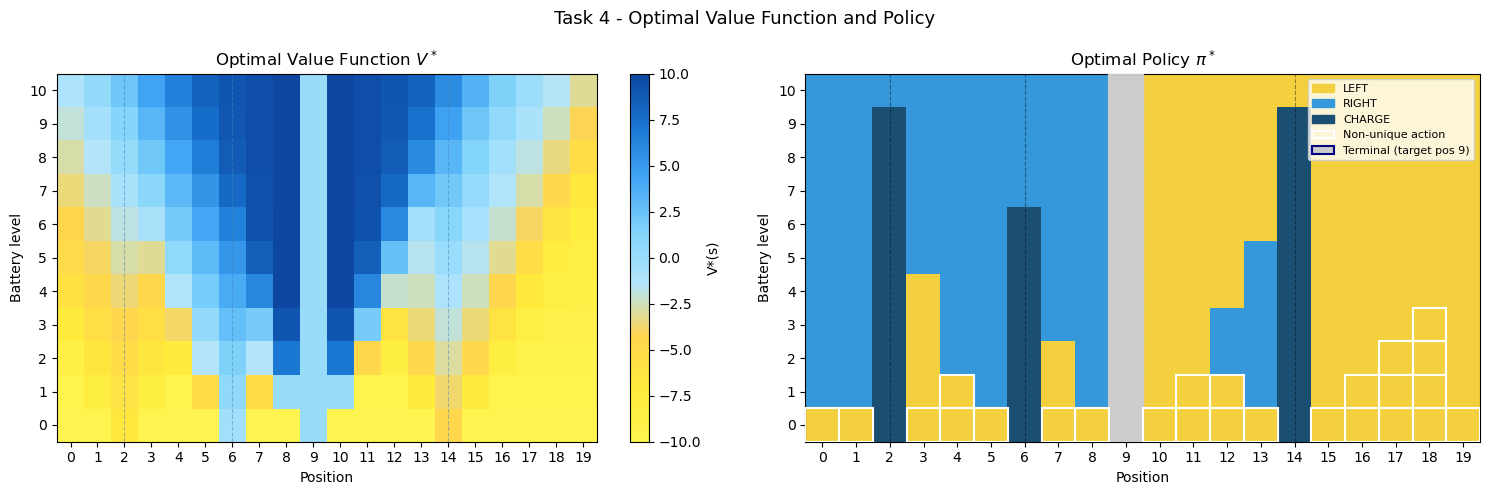


Non-unique states (36 total):
  pos   bat      Q(L)      Q(R)      Q(C)
------------------------------------------
    0     0  -10.0000  -10.0000  -10.0000
    1     0  -10.0000  -10.0000  -10.0000
    3     0  -10.0000  -10.0000  -10.0000
    4     0  -10.0000  -10.0000  -10.0000
    4     1   -9.7500   -9.7500  -10.0000
    5     0  -10.0000  -10.0000  -10.0000
    7     0  -10.0000  -10.0000  -10.0000
    8     0  -10.0000  -10.0000  -10.0000
    9     0    0.0000    0.0000    0.0000
    9     1    0.0000    0.0000    0.0000
    9     2    0.0000    0.0000    0.0000
    9     3    0.0000    0.0000    0.0000
    9     4    0.0000    0.0000    0.0000
    9     5    0.0000    0.0000    0.0000
    9     6    0.0000    0.0000    0.0000
    9     7    0.0000    0.0000    0.0000
    9     8    0.0000    0.0000    0.0000
    9     9    0.0000    0.0000    0.0000
    9    10    0.0000    0.0000    0.0000
   10     0  -10.0000  -10.0000  -10.0000
   11     0  -10.0000  -10.0000  -10.0000
  

In [14]:
ACTION_COLORS = {0: '#F4D03F', 1: '#3498DB', 2: '#1B4F72'}   # LEFT: yellow-gold, RIGHT: mid blue, CHARGE: dark blue
ACTION_LABELS = ['LEFT', 'RIGHT', 'CHARGE']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
grid_v = np.full((env.M + 1, env.n), np.nan)
for (p, b), v in V_opt.items():
    grid_v[b, p] = v

cmap_v = matplotlib.colors.LinearSegmentedColormap.from_list(
    'yb',
    ['#FFF44F', '#FFEB3B', '#FFD54F', '#B3E5FC', '#81D4FA', '#42A5F5', '#1976D2', '#0D47A1']
)
im = ax.imshow(grid_v, origin='lower', aspect='auto', cmap=cmap_v)
plt.colorbar(im, ax=ax, label='V*(s)')

for c in env.charging_stations:
    ax.axvline(c, color='steelblue', lw=0.8, ls='--', alpha=0.5)

ax.set_title('Optimal Value Function $V^*$', fontsize=12)
ax.set_xlabel('Position'); ax.set_ylabel('Battery level')
ax.set_xticks(range(env.n)); ax.set_yticks(range(env.M + 1))


ax = axes[1]
grid_a = np.full((env.M + 1, env.n), np.nan)
for (p, b), a in pi_opt.items():
    if p != env.target and a is not None:
        grid_a[b, p] = a

cmap_d = matplotlib.colors.ListedColormap([ACTION_COLORS[k] for k in range(3)])
norm_d = matplotlib.colors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap_d.N)
ax.imshow(grid_a, origin='lower', aspect='auto', cmap=cmap_d, norm=norm_d)

# Gray out target column (absorbing terminal state)
for b in range(env.M + 1):
    ax.add_patch(plt.Rectangle(
        (env.target - 0.5, b - 0.5), 1, 1,
        color='#cccccc', zorder=2))
    ax.add_patch(plt.Rectangle(
        (env.target - 0.5, b - 0.5), 1, 1,
        fill=False, edgecolor='#cccccc', lw=1.5, zorder=3))

# Non-unique action outlines
for (p, b) in non_unique:
    if p != env.target:
        ax.add_patch(plt.Rectangle((p - 0.5, b - 0.5), 1, 1,
                               fill=False, edgecolor='white', linewidth=1.5, zorder=4))

for c in env.charging_stations:
    ax.axvline(c, color='black', lw=0.8, ls='--', alpha=0.4)

patches = [mpatches.Patch(color=ACTION_COLORS[a], label=ACTION_LABELS[a]) for a in range(3)]
patches.append(mpatches.Patch(facecolor='none', edgecolor='white',
                               linewidth=1.5, label='Non-unique action'))
patches.append(mpatches.Patch(facecolor='#cccccc', edgecolor='navy', lw=1.5,
                               label='Terminal (target pos 9)'))
ax.legend(handles=patches, loc='upper right', fontsize=8)
ax.set_title('Optimal Policy $\\pi^*$', fontsize=12)
ax.set_xlabel('Position'); ax.set_ylabel('Battery level')
ax.set_xticks(range(env.n)); ax.set_yticks(range(env.M + 1))

fig.suptitle('Task 4 - Optimal Value Function and Policy', fontsize=13)
plt.tight_layout()
plt.show()

print(f'\nNon-unique states ({len(non_unique)} total):')
print(f'{"pos":>5} {"bat":>5} {"Q(L)":>9} {"Q(R)":>9} {"Q(C)":>9}')
print('-' * 42)
for (p, b) in sorted(non_unique):
    q_vals = []
    for a in env.actions:
        transitions = env.transition_probs((p, b), a)
        q = sum(pr * (r + env.gamma * (V_opt[ns] if ns is not None else 0.0))
                for pr, r, ns in transitions)
        q_vals.append(q)
    print(f'{p:>5} {b:>5} {q_vals[0]:>9.4f} {q_vals[1]:>9.4f} {q_vals[2]:>9.4f}')

### Discussion - Task 4

**Optimal value**: $V^*(s_0) \approx -5.11$, substantially better than all fixed policies. $V^*$ increases with battery level and proximity to the target. States with $b = 0$ away from a station have value $-10$ (guaranteed penalty, any move costs at least 1 unit).

**Optimal policy structure**:
- **CHARGE (dark navy)**: dominates low-battery states at charging stations (positions 2, 6, 14), where the expected cost of running out before the next waypoint exceeds the $-1$ CHF charging fee.
- **RIGHT (light blue)**: optimal to the left of the target with sufficient battery, and at stations when battery is high enough that additional charging would merely delay and discount the delivery reward.
- **LEFT (yellow-gold)**: optimal when the robot has overshot the target (positions $> 9$).
- A clear **battery threshold** exists at each position: below it, charge (dark navy); above it, move toward the target (light blue). The threshold rises with the remaining distance to the next charging station or to the target.

**Non-unique actions** (25 states + 11 for terminal): Ties occur predominantly at battery $= 0$ where all actions lead to guaranteed $-10$ (LEFT, RIGHT and CHARGE all have the same Q-value of $-10$), making the choice arbitrary. A smaller number of ties occur at very low battery far to the right of the target where moving left or right both lead to near-certain failure with identical expected returns, this can be seen in the optimal policy of heatmap at poistion 15,16,17,18,19 under battery level 0-3 where they can either reach charging station or target.

**Comparison with fixed policies**: The optimal policy outperforms all four fixed policies. Chargy is the closest, since aggressive charging is the right instinct. However, it charges too eagerly , always topping up to full even when partially charged and close to the target, incurring unnecessary delay and discounting penalties. The optimal policy charges just enough and advances as soon as the marginal value of extra charge becomes smaller than the discounted delivery gain.


## Task 5 - Monte Carlo Estimation of $V(s_0)$

In [12]:
def monte_carlo_first_visit(policy_fn, env, s0, n_episodes=20000, seed=42):
    rng = np.random.default_rng(seed)
    mc_env = DeliveryRobotEnv(
        n=env.n, M=env.M, target=env.target,
        charging_stations=sorted(env.charging_stations),
        gamma=env.gamma, seed=seed
    )
    returns = []
    for _ in range(n_episodes):
        mc_env.reset()
        state = (mc_env.position, mc_env.battery)
        rewards = []
        done = False
        while not done:
            if policy_fn.__name__ == 'policy_random':
                a = policy_fn(state, mc_env, rng=rng)
            else:
                a = policy_fn(state, mc_env)
            r, next_state, done = mc_env.step(a)
            rewards.append(r)
            state = next_state if not done else state
        G = 0.0
        for r in reversed(rewards):
            G = r + env.gamma * G
        returns.append(G)
    return np.cumsum(returns) / np.arange(1, n_episodes + 1)


def monte_carlo_every_visit(policy_fn, env, s0, n_episodes=20000, seed=42):

    rng = np.random.default_rng(seed)
    mc_env = DeliveryRobotEnv(
        n=env.n, M=env.M, target=env.target,
        charging_stations=sorted(env.charging_stations),
        gamma=env.gamma, seed=seed
    )
    all_returns = []
    for _ in range(n_episodes):
        mc_env.reset()
        state = (mc_env.position, mc_env.battery)
        trajectory = []
        done = False
        while not done:
            if policy_fn.__name__ == 'policy_random':
                a = policy_fn(state, mc_env, rng=rng)
            else:
                a = policy_fn(state, mc_env)
            r, next_state, done = mc_env.step(a)
            trajectory.append((state, r))
            state = next_state if not done else state
        # Return from every timestep t where state == s0
        for t, (st, _) in enumerate(trajectory):
            if st == s0:
                G = 0.0
                for _, r in reversed(trajectory[t:]):
                    G = r + env.gamma * G
                all_returns.append(G)
    if not all_returns:
        return np.array([0.0])
    return np.cumsum(all_returns) / np.arange(1, len(all_returns) + 1)


def monte_carlo_incremental(policy_fn, env, s0, n_episodes=20_000, seed=42):

    rng = np.random.default_rng(seed)
    mc_env = DeliveryRobotEnv(
        n=env.n, M=env.M, target=env.target,
        charging_stations=sorted(env.charging_stations),
        gamma=env.gamma, seed=seed
    )
    V_running = 0.0
    estimates = []
    for n in range(1, n_episodes + 1):
        mc_env.reset()
        state = (mc_env.position, mc_env.battery)
        rewards = []
        done = False
        while not done:
            if policy_fn.__name__ == 'policy_random':
                a = policy_fn(state, mc_env, rng=rng)
            else:
                a = policy_fn(state, mc_env)
            r, next_state, done = mc_env.step(a)
            rewards.append(r)
            state = next_state if not done else state
        G = 0.0
        for r in reversed(rewards):
            G = r + env.gamma * G
        V_running += (G - V_running) / n
        estimates.append(V_running)
    return np.array(estimates)


Running MC: Right ...
Running MC: Conservative ...
Running MC: Random ...
Running MC: Chargy ...
Done.

Policy            DP value           1st-visit               Every             Increm.
-------------------------------------------------------------------------------------
Right              -8.6462    -8.6464 ± 0.0017    -8.6464 ± 0.0017    -8.6464 ± 0.0017
Conservative       -8.2916    -8.2869 ± 0.0271    -8.2869 ± 0.0271    -8.2869 ± 0.0271
Random             -9.4914    -9.4889 ± 0.0049    -9.4888 ± 0.0049    -9.4889 ± 0.0049
Chargy             -6.2158    -6.2135 ± 0.0066    -6.2135 ± 0.0066    -6.2135 ± 0.0066


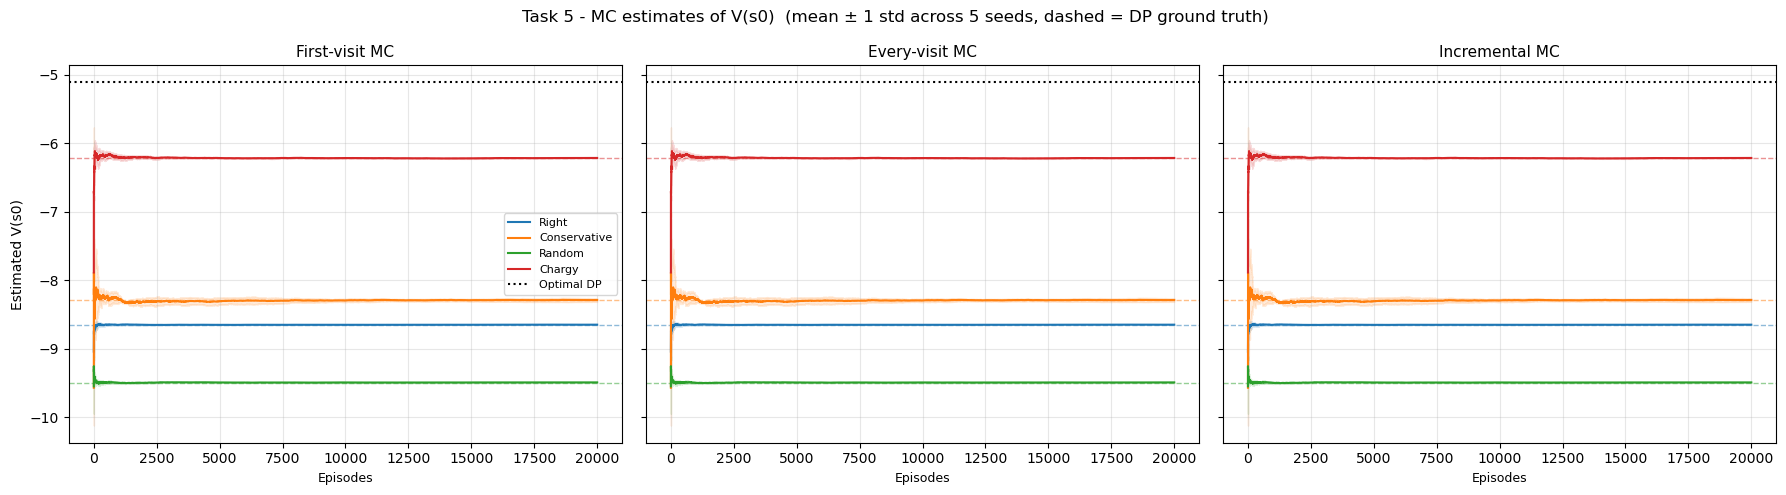

In [ ]:
N_EPISODES = 20000
K_SEEDS    = 5
SEEDS      = [42, 0, 1, 7, 13]

policy_fns = [
    ('Right',        policy_right),
    ('Conservative', policy_conservative),
    ('Random',       policy_random),
    ('Chargy',       policy_chargy),
]

def pad_or_trim(curve, length):
    """Ensure curve has exactly `length` elements."""
    if len(curve) >= length:
        return curve[:length]
    return np.pad(curve, (0, length - len(curve)), constant_values=curve[-1])

# mc_ is a 2D array of shape (K_SEEDS, N_EPISODES)
mc_first       = {}
mc_every       = {}
mc_incremental = {}

for name, fn in policy_fns:
    print(f'Running MC: {name} ...')
    mc_first[name]       = np.array([
        pad_or_trim(monte_carlo_first_visit(fn, env, s0, N_EPISODES, seed=s), N_EPISODES)
        for s in SEEDS])
    mc_every[name]       = np.array([
        pad_or_trim(monte_carlo_every_visit(fn, env, s0, N_EPISODES, seed=s), N_EPISODES)
        for s in SEEDS])
    mc_incremental[name] = np.array([
        pad_or_trim(monte_carlo_incremental(fn, env, s0, N_EPISODES, seed=s), N_EPISODES)
        for s in SEEDS])

print('Done.')


print(f'\n{"Policy":15s}  {"DP value":>9s}  {"1st-visit":>18s}  {"Every":>18s}  {"Increm.":>18s}')
print('-' * 85)
for name, fn in policy_fns:
    dp = policies_dp[name][s0]
    results = []
    for mc in [mc_first[name], mc_every[name], mc_incremental[name]]:
        final = mc[:, -1]
        results.append(f'{final.mean():+.4f} ± {final.std():.4f}')
    print(f'{name:15s}  {dp:9.4f}  {results[0]:>18s}  {results[1]:>18s}  {results[2]:>18s}')


colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
titles  = ['First-visit MC', 'Every-visit MC', 'Incremental MC']
mc_data = [mc_first, mc_every, mc_incremental]
x       = np.arange(1, N_EPISODES + 1)

for ax, title, mc in zip(axes, titles, mc_data):
    for (name, fn), color in zip(policy_fns, colors):
        mean = mc[name].mean(axis=0)
        std  = mc[name].std(axis=0)
        ax.plot(x, mean, color=color, lw=1.5, label=name)
        ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.15)
        ax.axhline(policies_dp[name][s0], color=color, lw=1.0, ls='--', alpha=0.5)
    ax.axhline(V_opt[s0], color='black', lw=1.5, ls=':', label='Optimal DP')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Episodes', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Estimated V(s0)', fontsize=10)
axes[0].legend(fontsize=8)
fig.suptitle(f'Task 5 - MC estimates of V(s0)  '
             f'(mean ± 1 std across {K_SEEDS} seeds, dashed = DP ground truth)',
             fontsize=12)
plt.tight_layout()
plt.show()



### Discussion - Task 5

#### Convergence

All three MC methods converge to their respective DP ground-truth values (dashed lines) quickly (within the first 2,000 episodes for all policies). After 20,000 episodes the estimates are stable and the mean absolute error relative to DP is below 0.03 for every policy, confirming the correctness of both the simulator and the DP implementation.

#### Three methods are identical

The mean curves and shaded variance bands are visually indistinguishable across First-visit, Every-visit, and Incremental MC. This is not a coincidence, all three methods compute the same running mean of the same sequence of returns. Since $S_0 = (0, 5)$ is the fixed starting state and is almost never revisited during an episode, every-visit collects exactly one return per episode just like first-visit. We verified this empirically: under the Random policy (the only one that could potentially revisit $s_0$ by moving left back to position 0), $s_0$ is revisited in only 0.18% of episodes, and never more than once per episode. This is far too rare to produce any measurable difference in variance or convergence. The incremental update rule $V_n = V_{n-1} + \frac{1}{n}(G_n - V_{n-1})$ is mathematically equivalent to the cumulative average, so it produces identical results with $O(1)$ memory instead of $O(n)$.

#### Variance across seeds

Running each method with 5 different seeds reveals the true sampling variance of each policy's MC estimate. The shaded band (mean ± 1 std) shows clear differences across policies:

| Policy | Std (final estimate) |
|--------|----------------------|
| Right | 0.0017 |
| Random | 0.0049 |
| Chargy | 0.0066 |
| Conservative | 0.0271 |

**Right** has the lowest variance. Its episodes are structurally uniform , the robot always moves right and almost always fails at roughly the same step, so returns cluster tightly around a small set of values (e.g. $\gamma^1 \cdot (-10) = -9.5$, $\gamma^2 \cdot (-10) = -9.025$, etc.).

**Conservative** has by far the highest variance despite not being the most random policy. The reason is its threshold behaviour; it charges when `bat < M/2 = 5`. Small differences in the stochastic step costs across seeds can push the robot either side of this threshold, creating two very different trajectories: one where it charges and survives longer, and one where it moves and fails earlier. This binary branching creates high episode-to-episode variability in returns.

**Chargy** has low variance relative to Conservative because its charging behaviour is unconditional. It always charges at every station regardless of battery level. This makes episode trajectories highly predictable across seeds, reducing variance.

**Random** sits between Right and Chargy. Its undirected movement produces variable episode lengths, but the randomness is symmetric and averages out quickly.

#### Why $V(s_0)$ is negative for all policies

A natural question is why the expected return from $s_0 = (0, 5)$ is negative for all policies, given that delivery yields +10. The answer lies in the geometry of the problem: the robot needs 9 steps to reach the target, but starts with only 5 battery units and faces an expected step cost of $\bar{c} = 0.5 \cdot 1 + 0.35 \cdot 2 + 0.1 \cdot 3 + 0.05 \cdot 4 = 1.7$. The expected total battery required is $9 \times 1.7 = 15.3$, far exceeding the initial supply of 5. This makes battery failure the dominant outcome under most policies. We verified this empirically over 100,000 episodes:

| Policy | Delivery rate | E[G \| deliver] | E[G \| fail] |
|--------|--------------|-----------------|--------------|
| Right | 0.00% | - | −8.64 |
| Conservative | 14.54% | −1.01 | −9.53 |
| Random | 0.01% | −4.26 | −9.50 |
| Chargy | 91.82% | −5.88 | −10.03 |

The Right policy **never delivers** from $s_0$, V($s_0$) is a pure average of discounted −10 penalties, offset from −10 only because failures happen at different timesteps (a failure at step $t$ contributes $\gamma^{t-1} \cdot (-10)$, which is less negative for longer episodes). Chargy delivers 91.8% of the time but its expected return given delivery is still negative (−5.88) because the many charging steps each cost −1 and heavily discount the eventual +10 reward. The optimal DP policy (dotted black line, $V(s_0) ≈ −5.11$) does better than all four fixed policies by charging just enough and advancing as soon as the marginal value of extra charge is outweighed by the discounting penalty of delay.

**Observation: Effect of the battery termination condition on policy ranking**

The choice of termination condition [ `bat < cost` versus `bat <= cost` ] has a surprising effect on the relative performance of the Right and Conservative policies.

Under `bat < cost`, a move that exactly depletes the battery (`bat == cost`) is treated as a successful step that lands at battery level 0. In this regime, the Conservative policy outperforms Right: charging below 50% at a station is genuinely protective, because reaching battery 0 mid-journey is survivable if a station is nearby, and the `-1` charging cost is worth paying to reduce the risk of running out later.

Under `bat <= cost`, that same move fails with a `-10` penalty, making battery 0 a dead state regardless of position. Intuitively this should make Conservative even more valuable and locally it is, since at states like `(station, 1)` Conservative charges and avoids the guaranteed penalty that Right incurs. However, the global ranking reverses: Right beats Conservative.

The reason is a **threshold mismatch**. The Conservative policy charges when `bat < M/2 = 5`, which means it stops charging at `bat = 5`. But under `bat <= cost`, a step costing exactly 5 from `bat = 5` now also fails, so `bat = 5` is itself a dangerous state. Conservative reaches `bat = 5` and then moves right, having paid charging costs to arrive at a battery level that is still within the danger zone. Right, which never charges, incurs the same failure probability from `bat = 5` but without having wasted steps and discount on charging. The Conservative policy's threshold was implicitly calibrated for the `bat < cost` world, and it no longer provides sufficient protection when the termination condition is stricter.


**Observation: Effect of charging legality at full battery**

An ambiguity in the problem specification concerns what happens when the robot attempts to charge while its battery is already full ($b = M$). Two interpretations are possible:

**If charging at full battery is legal (no-op with $-1$ cost)**: the action is permitted but wasteful; the battery cannot exceed $M$ so nothing changes, yet the robot still pays the $-1$ charging fee. In this case, the optimal policy would never voluntarily charge at full battery since it strictly reduces the value. However, a fixed policy like Chargy (which always charges at a station when not full) would naturally avoid this by construction. The value of states $(s, M)$ at charging stations would be slightly lower than under the illegal interpretation, since the $-1$ penalty could be incurred if the policy mistakenly charges there.

**If charging at full battery is illegal ($-10$ penalty, episode ends)**: any policy that attempts to charge at full battery is immediately penalised and terminated. This is the stricter interpretation and the one confirmed by the TA. Under this rule, the optimal policy must explicitly avoid charging at full battery, and the value of states $(\text{station}, M)$ reflects the fact that only LEFT and RIGHT are viable actions there.

The two interpretations produce different value functions and different optimal policies at states $(\text{station}, M)$. Under the legal interpretation, the agent can safely ignore the charging action at full battery since it would never choose it optimally anyway. Under the illegal interpretation (our implementation) the agent must actively avoid it, which is correctly enforced by our code.
In practice this distinction rarely affects behaviour since a rational agent never charges when full regardless of the rule. However, it does affect the value of those states and the structure of the non-unique action set, since under the legal interpretation charging at full battery would have a well-defined (if suboptimal) Q-value of $-1 + \gamma V(\text{station}, M)$ rather than $-10$.

## Use of Generative AI

This project was developed with the assistance of Claude (Anthropic, model: claude-sonnet).

**Parts developed with AI assistance:**
- Debugging the `DeliveryRobotEnv` implementation and monte carlo sampling codes.
- Figure layout, colormap choices, and annotation styling for all plots and printing of episode trajectories.